# Visualizations: Include relevant charts and support of findings.

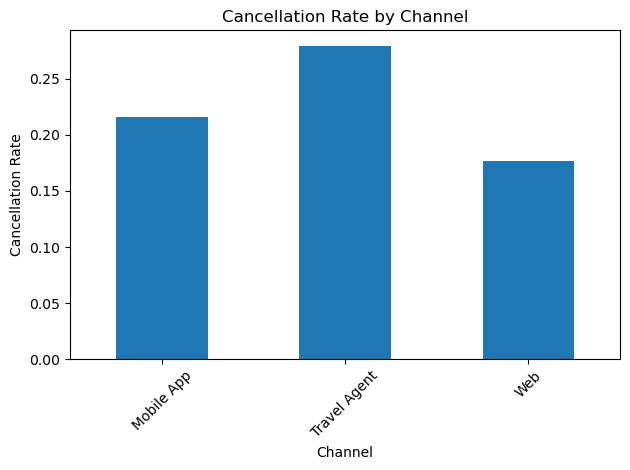

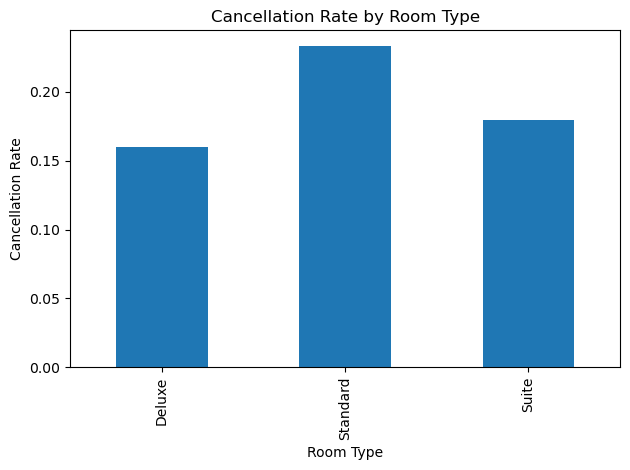

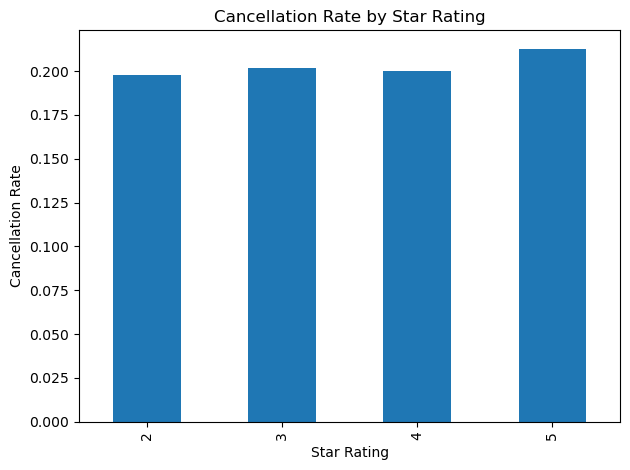

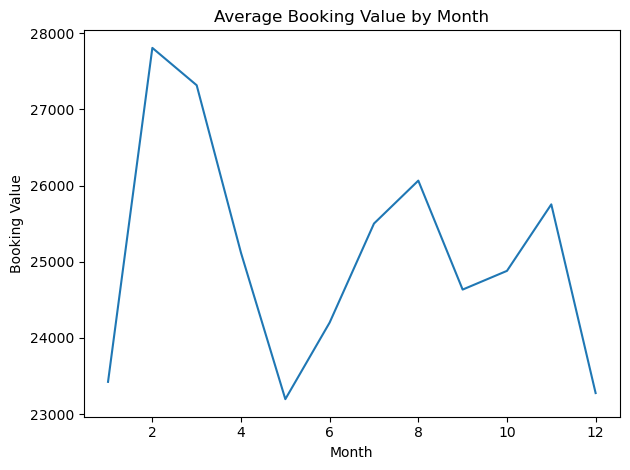

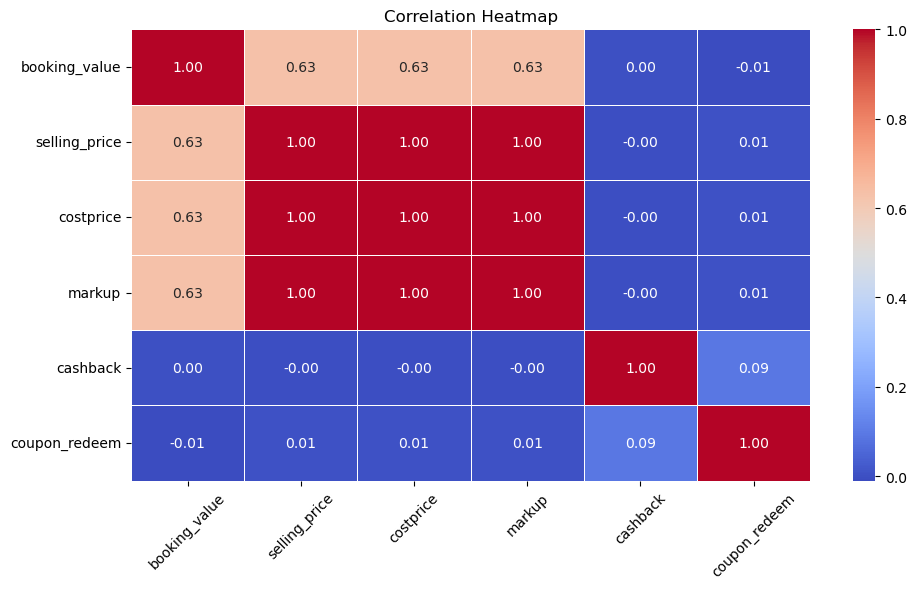

In [7]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 2. LOAD DATA
# ==============================
df = pd.read_csv("C:\\Users\\ASUS\\Downloads\\Hotel_bookings_final.csv.csv")

# ==============================
# 3. PREPROCESSING
# ==============================
# Convert dates
df['booking_date'] = pd.to_datetime(df['booking_date'], errors='coerce')

# Create cancellation flag
df['is_cancelled'] = df['booking_status'].str.lower().str.contains('cancel').astype(int)

# Extract month
df['month'] = df['booking_date'].dt.month

# ==============================
# 4. CANCELLATION BY CHANNEL
# ==============================
channel_cancel = df.groupby('booking_channel')['is_cancelled'].mean()

plt.figure()
channel_cancel.plot(kind='bar')
plt.title("Cancellation Rate by Channel")
plt.xlabel("Channel")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("1_channel_cancellation.png")
plt.show()

# ==============================
# 5. CANCELLATION BY ROOM TYPE
# ==============================
room_cancel = df.groupby('room_type')['is_cancelled'].mean()

plt.figure()
room_cancel.plot(kind='bar')
plt.title("Cancellation Rate by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Cancellation Rate")
plt.tight_layout()
plt.savefig("2_roomtype_cancellation.png")
plt.show()

# ==============================
# 6. CANCELLATION BY STAR RATING
# ==============================
star_cancel = df.groupby('star_rating')['is_cancelled'].mean()

plt.figure()
star_cancel.plot(kind='bar')
plt.title("Cancellation Rate by Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Cancellation Rate")
plt.tight_layout()
plt.savefig("3_star_cancellation.png")
plt.show()

# ==============================
# 7. MONTHLY BOOKING TREND
# ==============================
monthly_booking = df.groupby('month')['booking_value'].mean()

plt.figure()
monthly_booking.plot()
plt.title("Average Booking Value by Month")
plt.xlabel("Month")
plt.ylabel("Booking Value")
plt.tight_layout()
plt.savefig("4_monthly_trend.png")
plt.show()

# ==============================
# 8. HEATMAP (CLEAN)
# ==============================
important_cols = [
    'booking_value', 'selling_price', 'costprice',
    'markup', 'cashback', 'coupon_redeem'
]

plt.figure(figsize=(10,6))
sns.heatmap(
    df[important_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("5_heatmap.png")
plt.show()